### 1. Perkenalan Dataset

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

Sumber Dataset:
Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (Kaggle, UCI ML Repository, Open Data) atau data primer yang Anda kumpulkan sendiri.

### 2. Import Library

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Memuat Dataset

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
input_file = r'../churn_raw/churn.csv'
df = pd.read_csv(input_file)
df.head()

,Age,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,56.0,Male,0,150871.92,3,1,0,91690.50,0
1,69.0,Male,1,169116.98,2,0,1,21226.65,0
2,46.0,Male,7,201247.25,2,0,1,114213.29,1
3,32.0,Female,2,67455.18,3,1,1,185872.41,1
4,60.0,Male,9,NaN,2,0,0,166173.97,0


### 4. Exploratory Data Analysis (EDA)

Pada tahap ini, Anda akan melakukan Exploratory Data Analysis (EDA) untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              980 non-null    float64
 1   Gender           1000 non-null   object 
 2   Tenure           1000 non-null   int64  
 3   Balance          970 non-null    float64
 4   NumOfProducts    1000 non-null   int64  
 5   HasCrCard        1000 non-null   int64  
 6   IsActiveMember   1000 non-null   int64  
 7   EstimatedSalary  1000 non-null   float64
 8   Exited           1000 non-null   int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 70.4+ KB

Statistik Deskriptif:


,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,980.000000,1000.000000,970.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,43.797959,4.455000,124171.134649,2.01600,0.51000,0.485000,109530.525400,0.497000
std,15.018613,2.852738,72492.503278,0.82123,0.50015,0.500025,51635.408061,0.500241
min,18.000000,0.000000,2.910000,1.00000,0.00000,0.000000,20295.880000,0.000000
25%,31.000000,2.000000,64697.455000,1.00000,0.00000,0.000000,65651.812500,0.000000
50%,44.000000,4.000000,123420.080000,2.00000,1.00000,0.000000,109679.630000,0.000000
75%,56.000000,7.000000,188544.165000,3.00000,1.00000,1.000000,154796.352500,1.000000
max,69.000000,9.000000,249586.880000,3.00000,1.00000,1.000000,199828.910000,1.000000



Cek Missing Values:
Age                20
Gender              0
Tenure              0
Balance            30
NumOfProducts       0
HasCrCard           0
IsActiveMember      0
EstimatedSalary     0
Exited              0
dtype: int64


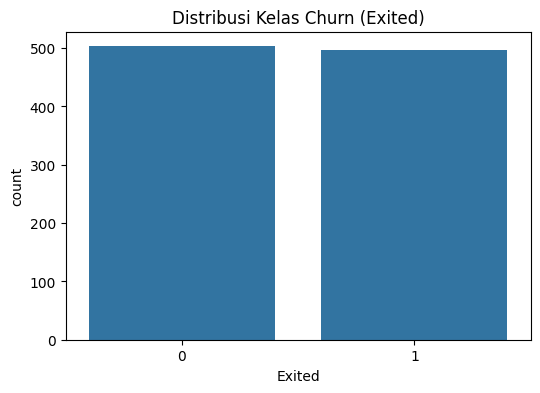

In [3]:
print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nCek Missing Values:")
print(df.isnull().sum())

plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title('Distribusi Kelas Churn (Exited)')
plt.show()

### 5. Data Preprocessing

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi tidak terbatas pada:

- Menghapus atau Menangani Data Kosong (Missing Values)
- Menghapus Data Duplikat
- Normalisasi atau Standarisasi Fitur
- Deteksi dan Penanganan Outlier
- Encoding Data Kategorikal
- Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Balance'] = df['Balance'].fillna(df['Balance'].mean())

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

scaler = StandardScaler()
scaled_features = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
df[scaled_features] = scaler.fit_transform(df[scaled_features])
df.head()

,Age,Gender,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.820855,1,-1.562439,3.741701e-01,1.198803,1,0,-0.345673,0
1,1.695681,1,-1.211723,6.298463e-01,-0.019493,0,1,-1.710998,0
2,0.147913,1,0.892572,1.080102e+00,-0.019493,0,1,0.090734,1
3,-0.794207,0,-0.861007,-7.947861e-01,1.198803,1,1,1.479219,1
4,1.090032,1,1.594004,-2.039225e-16,-0.019493,0,0,1.097537,0


In [5]:
output_dir = 'churn_preprocessing'
os.makedirs(output_dir, exist_ok=True)
df.to_csv(os.path.join(output_dir, 'churn_processed.csv'), index=False)
print('Data preprocessing saved!')

Data preprocessing saved!
